<a href="https://colab.research.google.com/github/RichardGonow/RichardGonow/blob/main/%E4%B8%93%E4%B8%9A02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#数据读取与清洗（防 NaN 崩溃）
import pandas as pd
import numpy as np

df = pd.read_csv("HW1-Data.csv")

# 删除目标缺失
df = df.dropna(subset=["UTS"])

y = df["UTS"]

# EL 不参与建模（避免信息泄漏）
X = df.drop(columns=["UTS", "EL"])

# 缺失值用中位数
X = X.fillna(X.median())


In [2]:
from sklearn.feature_selection import VarianceThreshold

var_selector = VarianceThreshold(threshold=0.01)
X_var = var_selector.fit_transform(X)

print("原始特征数:", X.shape[1])
print("方差筛选后:", X_var.shape[1])


原始特征数: 15
方差筛选后: 8


In [3]:
#方差筛选（第一道降维）
from sklearn.feature_selection import VarianceThreshold

var_selector = VarianceThreshold(threshold=0.01)
X_var = var_selector.fit_transform(X)

print("原始特征数:", X.shape[1])
print("方差筛选后:", X_var.shape[1])


原始特征数: 15
方差筛选后: 8


In [4]:
#标准化（LASSO 必须
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_var)


In [5]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(
    alphas=np.logspace(-4, 1, 50),
    cv=5,
    random_state=0
)

lasso.fit(X_scaled, y)

selected_idx = np.where(lasso.coef_ != 0)[0]
X_lasso = X_scaled[:, selected_idx]

print("LASSO 选中特征数:", len(selected_idx))


LASSO 选中特征数: 6


In [6]:
#增强解释性
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector

n_features = X_scaled.shape[1]
n_select = min(6, n_features - 1)

lr = LinearRegression()

sfs = SequentialFeatureSelector(
    lr,
    n_features_to_select=n_select,
    direction="forward",
    cv=5
)

X_forward = sfs.fit_transform(X_scaled, y)


In [7]:
from sklearn.model_selection import cross_val_score

lasso_r2 = cross_val_score(
    lasso, X_lasso, y, cv=5, scoring="r2"
).mean()

forward_r2 = cross_val_score(
    lr, X_forward, y, cv=5, scoring="r2"
).mean()

print("LASSO R²:", round(lasso_r2, 3))
print("Forward R²:", round(forward_r2, 3))


LASSO R²: 0.429
Forward R²: 0.423


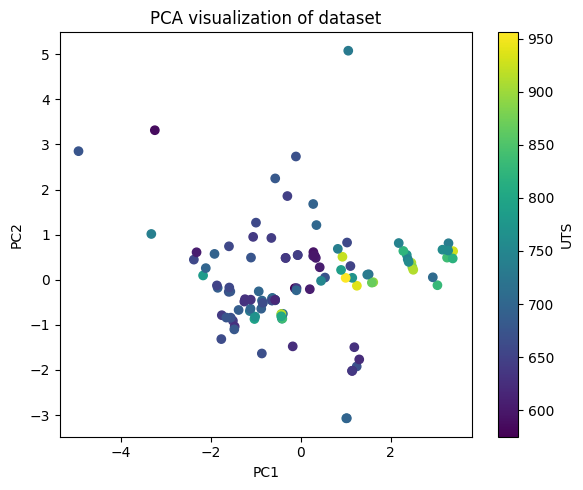

In [8]:
#可视化
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="UTS")
plt.title("PCA visualization of dataset")
plt.tight_layout()
plt.show()
